## Notebook to obtain the DFT descriptors for Au-based drugs, step by step:

In [1]:
Au_directory = "/home/ubuntu/Documents/PX-UdG/metallodrugs/Au"

%cd {Au_directory}

/home/ubuntu/Documents/PX-UdG/metallodrugs/Au


In [2]:
!rm *.sdf
!rm *txt

In [3]:
import os,re,sys,pickle,datetime,time,random,itertools,glob
import warnings
warnings.filterwarnings("ignore")
import openpyxl
import pandas as pd
from rdkit import Chem
import get_properties_functions as gp

### The first step, once we have the *.log files, is to create the *sdf files, which will be used as input for the descriptor calculations. I will classify by metal fos simpicity:

In [4]:
!module load openbabel
!obabel *.log -osdf -m  
!ls *.log > log_ids.txt
!cat *.sdf >> molecules_to_fix.sdf

/bin/bash: line 1: module: command not found
45 molecules converted
45 files output. The first is auranofin-conf_10.sdf


### The molecules.sdfs file has been created containing all the structures and confromers of the Au-based metallodrugs. The next step is to homogenize the atom numbers so that the property extraction is easier:

### At this point the molecules.sdf file is ready to be used as input file for the computation of molecular properties. 

We need to define the SMARTS substructure for which we want to compute the descriptors, but if we do not know it, we can compute it with the following code:

Common Substructure SMARTS: [#79]-[#16]


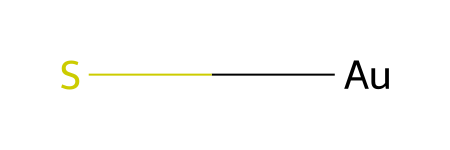

In [5]:
from rdkit import Chem
from rdkit.Chem import rdFMCS

# 1. Load molecules
suppl = Chem.SDMolSupplier('molecules_to_fix.sdf', sanitize=False, removeHs=False)
mols = [m for m in suppl if m is not None]

if not mols:
    print("No molecules found.")
else:
    # 2. Setup the Parameters Object explicitly
    params = rdFMCS.MCSParameters()
    
    # Configure the parameters safely
    params.MaximizeBonds = False # We want to maximize ATOMS instead
    params.Threshold = 1.0       # Must be present in 100% of molecules
    params.AtomCompare = rdFMCS.AtomCompare.CompareElements
    params.BondCompare = rdFMCS.BondCompare.CompareOrder
    params.CompleteRingsOnly = False

    # 3. Run MCS using the parameters object
    res = rdFMCS.FindMCS(mols, params)

    # 4. Output
    common_smarts = res.smartsString
    print(f"Common Substructure SMARTS: {common_smarts}")

    # Visualize
    if common_smarts:
        common_mol = Chem.MolFromSmarts(common_smarts)
        display(common_mol)
    else:
        print("No common substructure found at 100% threshold.")

In [6]:
substructure = Chem.MolFromSmarts('[Au]-[S]')

Now I will generate a preliminary dataframe with the structure names. In this case are all Pt-based drugs and their conformers:

In [7]:
from rdkit import Chem
import numpy as np

def get_reordered_indices(mol, metal_symbol="Au", ligand_symbol="S"):
    """Returns the new list of indices [metal, nearest_S, ...] based on 3D distance."""
    atoms = mol.GetAtoms()
    
    # 1. Find the Metal (Au)
    metal_indices = [a.GetIdx() for a in atoms if a.GetSymbol() == metal_symbol]
    if not metal_indices:
        # If no metal is found, return original order
        return list(range(mol.GetNumAtoms()))
    
    metal_idx = metal_indices[0]
    
    # 2. Find all Sulfur (S) atoms
    s_indices = [a.GetIdx() for a in atoms if a.GetSymbol() == ligand_symbol]
    
    new_order = [metal_idx]
    
    if s_indices:
        # 3. Calculate 3D distances to find the closest S
        try:
            conf = mol.GetConformer()
            metal_pos = np.array(conf.GetAtomPosition(metal_idx))
            
            distances = []
            for s_idx in s_indices:
                s_pos = np.array(conf.GetAtomPosition(s_idx))
                dist = np.linalg.norm(metal_pos - s_pos)
                distances.append((dist, s_idx))
            
            # Sort by distance (shortest first) and take the index
            distances.sort()
            closest_s_idx = distances[0][1]
            new_order.append(closest_s_idx)
        except ValueError:
            # Fallback if no 3D coordinates exist: take the first S found
            new_order.append(s_indices[0])

    # 4. Fill in the remaining atoms in their original relative order
    used = set(new_order)
    for a in atoms:
        idx = a.GetIdx()
        if idx not in used:
            new_order.append(idx)
            
    return new_order

input_path = 'molecules_to_fix.sdf'
output_path = 'molecules.sdf'

# removeHs=False preserves the atom count/indexing from the source file
suppl = Chem.SDMolSupplier(input_path, removeHs=False, sanitize=False)

with open(input_path, 'r') as f_in, open(output_path, 'w') as f_out:
    # Split by the SDF terminator
    all_content = f_in.read().split('$$$$\n')
    
    for i, mol_block in enumerate(all_content):
        if not mol_block.strip(): 
            continue
        
        rd_mol = suppl[i]
        if not rd_mol: 
            continue
        
        # Get the mapping (0-indexed)
        new_order = get_reordered_indices(rd_mol)
        
        # Create a reverse lookup: mapping[old_idx] = new_1_based_idx
        mapping = {old: new + 1 for new, old in enumerate(new_order)}
        
        lines = mol_block.splitlines()
        if len(lines) < 4: 
            continue
            
        counts_line = lines[3]
        num_atoms = int(counts_line[:3])
        num_bonds = int(counts_line[3:6])
        
        header = lines[:3]
        atom_lines = lines[4 : 4 + num_atoms]
        bond_lines = lines[4 + num_atoms : 4 + num_atoms + num_bonds]
        footer = lines[4 + num_atoms + num_bonds:]
        
        # 1. Write Header and Counts
        f_out.write("\n".join(header) + "\n")
        f_out.write(counts_line + "\n")
        
        # 2. Write Atoms in NEW order
        for idx in new_order:
            f_out.write(atom_lines[idx] + "\n")
            
        # 3. Write Bonds with UPDATED indices
        for b_line in bond_lines:
            # SDF V2000 uses 3-character widths for indices
            a1_old = int(b_line[0:3]) - 1
            a2_old = int(b_line[3:6]) - 1
            
            a1_new = mapping[a1_old]
            a2_new = mapping[a2_old] # Fixed: used a2_old instead of a2_new
            
            remainder = b_line[6:]
            f_out.write(f"{a1_new:>3}{a2_new:>3}{remainder}\n")
            
        # 4. Write Footer
        f_out.write("\n".join(footer) + "\n$$$$\n")

print(f"Done! Reordered molecules saved to {output_path}")

Done! Reordered molecules saved to molecules.sdf


In [8]:
import pandas as pd
#generate a list of molecules using RDkit
all_compounds = Chem.SDMolSupplier('molecules.sdf', removeHs=False)
#molecules.sdf is generated with the instructions above
#it is a single sdf that contains the structures/atom numbers etc. for every molecule you will analyze

#uses RDKit to search for the substructure in each compound you will analyze
atoms = []
for molecule in all_compounds:
    if molecule is not None:
        submatch = molecule.GetSubstructMatches(substructure) #find substructure
        matchlist = list([item for sublist in submatch for item in sublist]) #list of zero-indexed atom numbers
        match_idx = [x+1 for x in matchlist] #this line changes from 0-indexed to 1-indexed (for Gaussian)
        atoms.append(match_idx) #append 1-indexed list to atoms (a list of lists)

#this loop extracts log names from log_ids and splits them to the desired format
filenames = open("log_ids.txt", "r") #generate this with instruction above
#it is a text file that contains the file name for every molecule you will analyze
list_of_filenames = [(line.strip()).split() for line in filenames] #list of the file names (each of which includes all conformers)
list_of_files = []
for filename in list_of_filenames:
    file = filename[0].split(".")
    list_of_files.append(file[0])
filenames.close()

#put the atom numbers for the substructure for each log file into a dataframe
prelim_df = pd.DataFrame(atoms)
index=list_of_files
prelim_df.insert(0,column='log_name',value=list_of_files)
prelim_df = prelim_df.iloc[:, :3]
display(prelim_df)

,log_name,0,1
0,auranofin-conf_10,1,2
1,auranofin-conf_1,1,2
2,auranofin-conf_3,1,2
3,auranofin-conf_4,1,2
4,auranofin-conf_5,1,2
5,auranofin-conf_6,1,2
6,auranofin-conf_7,1,2
7,auranofin-conf_8,1,2
8,auranofin-conf_9,1,2
9,auranofin,1,2


Now I will label the atoms that will make things easier to then compute the properties, and I will print the labelled dataframe:

The mapping dataframe can also be imported in case it is done manually. Check the original notebook for detailed information.

In [9]:
atom_labels = {'log_name': 'log_name',
                0: 'Au',
                1: 'S',
                }

In [10]:
#rename columns using the user input above
atom_map_df = prelim_df.rename(columns=atom_labels)
display(atom_map_df)

#you can use this to clean up the table if you have more atoms in your substructure than you want to collect descriptors for
#atom_map_df = atom_map_df.drop(columns= ['C4', 'C1'])
#display(atom_map_df.head())

df = atom_map_df #df is what properties will be appended to, this creates a copy so that you have the original preserved

,log_name,Au,S
0,auranofin-conf_10,1,2
1,auranofin-conf_1,1,2
2,auranofin-conf_3,1,2
3,auranofin-conf_4,1,2
4,auranofin-conf_5,1,2
5,auranofin-conf_6,1,2
6,auranofin-conf_7,1,2
7,auranofin-conf_8,1,2
8,auranofin-conf_9,1,2
9,auranofin,1,2


## Get available properties

From now on, I will collect descriptors based on chemical knowledge. In the case of Pt, I will look at molecular properties and also local properties regarding the substructure (N-Pd-N)

In [11]:
df = atom_map_df

#---------------GoodVibes Engergies---------------
#uses the GoodVibes 2021 Branch (Jupyter Notebook Compatible)
#calculates the quasi harmonic corrected G(T) and single point corrected G(T) as well as other thermodynamic properties
#inputs: dataframe, temperature
#df = gp.get_goodvibes_e(df, 298.15)

#---------------Frontier Orbitals-----------------
#E(HOMO), E(LUMO), mu(chemical potential or negative of molecular electronegativity), eta(hardness/softness), omega(electrophilicity index)
df = gp.get_frontierorbs(df)

#---------------Polarizability--------------------
#Exact polarizability
df = gp.get_polarizability(df)

#---------------Dipole----------------------------
#Total dipole moment magnitude in Debye
df = gp.get_dipole(df)

#---------------Volume----------------------------
#Molar volume
#requires the Gaussian keyword = "volume" in the .com file
#df = gp.get_volume(df)

#---------------SASA------------------------------
#Uses morfeus to calculat sovlent accessible surface area and the volume under the SASA
df = gp.get_SASA(df)

#---------------NBO-------------------------------
#natural charge from NBO
#requires the Gaussian keyword = "pop=nbo7" in the .com file
nbo_list = ["Pt", "N1", "N2"]
#df = gp.get_nbo(df, nbo_list)

#---------------NMR-------------------------------
#isotropic NMR shift
#requires the Gaussian keyword = "nmr=giao" in the .com file
nmr_list = ["Au", "S"]
#df = gp.get_nmr_isotropic_shielding(df, nmr_list)

#---------------Distance--------------------------
#distance between 2 atoms
dist_list_of_lists = [["Au", "S"]]
df = gp.get_distance(df, dist_list_of_lists)

#---------------Angle-----------------------------
#angle between 3 atoms
angle_list_of_lists = [["N1", "Pt", "N2"]]
#df = gp.get_angles(df, angle_list_of_lists)

#---------------Dihedral--------------------------
#dihedral angle between 4 atoms
dihedral_list_of_lists = [["O2", "C1", "O3", "H5"], ["C4", "C1", "O3", "H5"]]
#df = gp.get_dihedral(df, dihedral_list_of_lists)

#---------------Vbur Scan-------------------------
#uses morfeus to calculate the buried volume at a series of radii (including hydrogens)
#inputs: dataframe, list of atoms, start_radius, end_radius, and step_size
#if you only want a single radius, put the same value for start_radius and end_radius (keep step_size > 0)
vbur_list = ["Au", "S"]
df = gp.get_vbur_scan(df, vbur_list, 2, 4, 0.5)

#---------------Sterimol morfeus------------------
#uses morfeus to calculate Sterimol L, B1, and B5 values
#NOTE: this is much faster than the corresponding DBSTEP function (recommendation: use as default/if you don't need Sterimol2Vec)
sterimol_list_of_lists = [["Au", "S"]]
#df = gp.get_sterimol_morfeus(df, sterimol_list_of_lists)

#---------------Buried Sterimol-------------------
#uses morfeus to calculate Sterimol L, B1, and B5 values within a given sphere of radius r_buried
#atoms outside the sphere + 0.5 vdW radius are deleted and the Sterimol vectors are calculated
#for more information: https://kjelljorner.github.io/morfeus/sterimol.html
#inputs: dataframe, list of atom pairs, r_buried
sterimol_list_of_lists = [["Au", "S"]]
#df = gp.get_buried_sterimol(df, sterimol_list_of_lists, 5.5)

#---------------Sterimol DBSTEP-------------------
#uses DBSTEP to calculate Sterimol L, B1, and B5 values
#default grid point spacing (0.05 Angstrom) is used (can use custom spacing or vdw radii in the get_properties_functions script)
#more info here: https://github.com/patonlab/DBSTEP
#NOTE: this takes longer than the morfeus function (recommendation: only use this if you need Sterimol2Vec)
sterimol_list_of_lists = [["Au", "S"]]
#df = gp.get_sterimol_dbstep(df, sterimol_list_of_lists)

#---------------Sterimol2Vec----------------------
#uses DBSTEP to calculate Sterimol Bmin and Bmax values at intervals from 0 to end_radius, with a given step_size
#default grid point spacing (0.05 Angstrom) is used (can use custom spacing or vdw radii in the get_properties_functions script)
#more info here: https://github.com/patonlab/DBSTEP
#inputs: dataframe, list of atom pairs, end_radius, and step_size
sterimol2vec_list_of_lists = [["Au", "S"]]
#df = gp.get_sterimol2vec(df, sterimol2vec_list_of_lists, 1, 1.0)

#---------------Pyramidalization------------------
#uses morfeus to calculate pyramidalization based on the 3 atoms in closest proximity to the defined atom
#collects values based on two definitions of pyramidalization
#details on these values can be found here: https://kjelljorner.github.io/morfeus/pyramidalization.html
pyr_list = ["C1", "C4"]
#df = gp.get_pyramidalization(df, pyr_list)

#---------------Plane Angle-----------------------
#plane angle between 2 planes (each defined by 3 atoms)
planeangle_list_of_lists = [["O2", "C1", "O3", "H5", "C1", "C4"], ["O2", "C1", "O3", "H5", "C1", "C4"]]
#df = gp.get_planeangle(df, planeangle_list_of_lists)

#---------------Time----------------------------------
#returns the total CPU time and total Wall time
#if used in summary df, will give the average (not Boltzmann average) in the Boltzmann average column
#df = gp.get_time(df)

#---------------ChelpG----------------------------
#ChelpG ESP charge
#requires the Gaussian keyword = "pop=chelpg" in the .com file
a_list = ["Au", "S"]
#df = gp.get_chelpg(df, a_list)

#---------------Hirshfeld-------------------------
#Hirshfeld charge, CM5 charge, Hirshfeld atom dipole
#requires the Gaussian keyword = "pop=hirshfeld" in the .com file
a_list = ["Au", "S"]
#df = gp.get_hirshfeld(df, a_list)

#---------------IR--------------------------------
#CAUTION: CANNOT ACCURATELY IDENTIFY ATOM STRETCHES IN SOME CASES (struggles if there is more than one stretch in the defined range)
#IR frequencies and intensities in a specific range (for specific atoms)
#requires the Gaussian keyword = "freq=noraman" in the .com file
#inputs: dataframe, atom1, atom2, frequency_min, frequency_max, intensity_min, intensity_max, threshold
#if you want to collect multiple IR frequencies, you will need to copy/paste this function for each stretch
#we recommend a threshold of 0.0 (may have to adjust)
#df = gp.get_IR(df, "Pt", "N1", 100, 4000, 100, 800, 0.0)
#df = gp.get_IR(df, "Pt", "N2", 100, 4000, 100, 800, 0.0)

pd.options.display.max_columns = None

display(df)


Frontier orbitals function has completed
Polarizability function has completed
Dipole function has completed
SASA function has completed
Distance function has completed for [['Au', 'S']]
Vbur scan function has completed for ['Au', 'S'] from 2  to  4


,log_name,Au,S,HOMO,LUMO,μ,η,ω,polar_iso(au),polar_aniso(au),dipole(Debye),SASA_surface_area(Å²),SASA_volume(Å³),SASA_sphericity,distance_Au_S(Å),%Vbur_Au_2.0Å,%Vbur_S_2.0Å,%Vbur_Au_2.5Å,%Vbur_S_2.5Å,%Vbur_Au_3.0Å,%Vbur_S_3.0Å,%Vbur_Au_3.5Å,%Vbur_S_3.5Å,%Vbur_Au_4.0Å,%Vbur_S_4.0Å
0,auranofin-conf_10,1,2,-0.19412,-0.00923,-0.101675,0.18489,0.02796,316.746,61.4853,4.8369,661.867989,1234.924623,0.841020,2.65347,59.145790,94.143853,54.736945,92.658549,52.051363,91.079410,49.410641,87.287435,46.313854,81.410605
1,auranofin-conf_1,1,2,-0.19694,-0.01131,-0.104125,0.18563,0.02920,318.059,81.6296,6.7622,672.587783,1257.451664,0.837650,2.65958,59.410511,93.649923,55.182967,92.547858,52.637068,91.009572,50.075708,87.110394,47.245671,80.643660
2,auranofin-conf_3,1,2,-0.19474,-0.00779,-0.101265,0.18695,0.02743,316.085,61.5791,4.6686,655.718042,1230.335153,0.846803,2.65310,59.152247,94.076059,54.762990,92.678083,52.119338,91.101758,49.425783,87.299082,46.491528,81.415260
3,auranofin-conf_4,1,2,-0.19474,-0.00779,-0.101265,0.18695,0.02743,316.084,61.5796,4.6680,655.368046,1229.775867,0.846999,2.65311,59.161932,94.088972,54.759734,92.671572,52.102577,91.101758,49.419377,87.305488,46.493855,81.410992
4,auranofin-conf_5,1,2,-0.19552,-0.01031,-0.102915,0.18521,0.02859,318.267,70.9042,7.0717,677.487649,1255.737969,0.830836,2.65610,59.258781,93.872676,54.649043,92.583670,51.851162,91.033783,49.246995,87.201244,46.407346,81.103749
5,auranofin-conf_6,1,2,-0.19548,-0.01030,-0.102890,0.18518,0.02858,318.279,70.9082,7.0752,677.587652,1255.897550,0.830784,2.65623,59.252324,93.853306,54.618114,92.564136,51.799017,90.995605,49.205647,87.175037,46.376699,81.091723
6,auranofin-conf_7,1,2,-0.19693,-0.01131,-0.104120,0.18562,0.02920,318.063,81.6406,6.7627,672.687775,1257.603660,0.837593,2.65959,59.452479,93.675749,55.187850,92.583670,52.626825,91.045888,50.058819,87.139513,47.229377,80.632022
7,auranofin-conf_8,1,2,-0.19628,-0.01282,-0.104550,0.18346,0.02979,318.719,79.8104,6.9801,678.507743,1260.973806,0.831892,2.65963,59.387913,93.678977,55.130876,92.560880,52.527190,91.003054,49.983694,87.124371,46.967134,80.662668
8,auranofin-conf_9,1,2,-0.19630,-0.01226,-0.104280,0.18404,0.02954,318.586,81.7124,6.9724,676.007763,1260.190071,0.834622,2.65957,59.400826,93.591813,55.072275,92.276013,52.467595,90.824270,49.912062,86.965966,46.918255,80.557926
9,auranofin,1,2,-0.19609,-0.01952,-0.107805,0.17657,0.03291,317.804,63.2787,9.2728,666.927297,1250.047443,0.841440,2.68096,59.345945,87.716296,54.466727,84.599232,50.486070,82.654201,46.540719,78.627003,42.398439,72.469508


In [12]:
#for numerically named compounds, prefix is any text common to all BEFORE the number and suffix is common to all AFTER the number
#this is a template for our files that are all named "AcXXX_clust-X.log" or "AcXXX_conf-X.log"
prefix = ""
suffix = "_conf-"

#columns that provide atom mapping information are dropped
atom_columns_to_drop = ["Au", "S"]

#title of the column for the energy you want to use for boltzmann averaging and lowest E conformer determination
energy_col_header = "G(T)_spc(Hartree)"


energy_cutoff = 4.2 #specify energy cutoff in kcal/mol to remove conformers above this value before post-processing
verbose = False #set to true if you'd like to see info on the nunmber of conformers removed for each compound

In [13]:
import subprocess
import re
import pandas as pd

# 1. Prepare the file list
file_list = [str(name) + ".log" for name in df['log_name']]

print(f"Parsing energies for {len(file_list)} files...")

# 2. Run GoodVibes (without --csv to keep the standard table format)
cmd = ["python", "-m", "goodvibes", "--qh", "grimme", "-t", "298.15"] + file_list

try:
    result = subprocess.run(cmd, capture_output=True, text=True, check=True)
    raw_text = result.stdout

    # 3. REGEX MAGIC
    # This looks for:
    # 'o' + space + (the name) + some space + (a bunch of numbers) + (the final energy)
    # The final number in the GoodVibes table is always the qh-Gibbs energy.
    pattern = r"o\s+([\w-]+)\s+.*?\s+(-?\d+\.\d+)\s*$"
    
    energy_map = {}
    for line in raw_text.splitlines():
        match = re.search(pattern, line.strip())
        if match:
            structure_name = match.group(1)
            final_energy = float(match.group(2))
            energy_map[structure_name] = final_energy

    # 4. Map back to your dataframe
    # We ensure both sides are strings and stripped of whitespace
    df[energy_col_header] = df['log_name'].astype(str).str.strip().map(energy_map)

    # 5. Report Results
    success_count = df[energy_col_header].notnull().sum()
    print(f"Successfully extracted {success_count} / {len(df)} energies.")
    
    if success_count < len(df):
        print("Missing structures in output:", df[df[energy_col_header].isnull()]['log_name'].tolist())

except Exception as e:
    print(f"An error occurred during parsing: {e}")

Parsing energies for 45 files...
Successfully extracted 45 / 45 energies.


In [14]:
display(df)

,log_name,Au,S,HOMO,LUMO,μ,η,ω,polar_iso(au),polar_aniso(au),dipole(Debye),SASA_surface_area(Å²),SASA_volume(Å³),SASA_sphericity,distance_Au_S(Å),%Vbur_Au_2.0Å,%Vbur_S_2.0Å,%Vbur_Au_2.5Å,%Vbur_S_2.5Å,%Vbur_Au_3.0Å,%Vbur_S_3.0Å,%Vbur_Au_3.5Å,%Vbur_S_3.5Å,%Vbur_Au_4.0Å,%Vbur_S_4.0Å,G(T)_spc(Hartree)
0,auranofin-conf_10,1,2,-0.19412,-0.00923,-0.101675,0.18489,0.02796,316.746,61.4853,4.8369,661.867989,1234.924623,0.841020,2.65347,59.145790,94.143853,54.736945,92.658549,52.051363,91.079410,49.410641,87.287435,46.313854,81.410605,-2334.838710
1,auranofin-conf_1,1,2,-0.19694,-0.01131,-0.104125,0.18563,0.02920,318.059,81.6296,6.7622,672.587783,1257.451664,0.837650,2.65958,59.410511,93.649923,55.182967,92.547858,52.637068,91.009572,50.075708,87.110394,47.245671,80.643660,-2334.842635
2,auranofin-conf_3,1,2,-0.19474,-0.00779,-0.101265,0.18695,0.02743,316.085,61.5791,4.6686,655.718042,1230.335153,0.846803,2.65310,59.152247,94.076059,54.762990,92.678083,52.119338,91.101758,49.425783,87.299082,46.491528,81.415260,-2334.839471
3,auranofin-conf_4,1,2,-0.19474,-0.00779,-0.101265,0.18695,0.02743,316.084,61.5796,4.6680,655.368046,1229.775867,0.846999,2.65311,59.161932,94.088972,54.759734,92.671572,52.102577,91.101758,49.419377,87.305488,46.493855,81.410992,-2334.839471
4,auranofin-conf_5,1,2,-0.19552,-0.01031,-0.102915,0.18521,0.02859,318.267,70.9042,7.0717,677.487649,1255.737969,0.830836,2.65610,59.258781,93.872676,54.649043,92.583670,51.851162,91.033783,49.246995,87.201244,46.407346,81.103749,-2334.844067
5,auranofin-conf_6,1,2,-0.19548,-0.01030,-0.102890,0.18518,0.02858,318.279,70.9082,7.0752,677.587652,1255.897550,0.830784,2.65623,59.252324,93.853306,54.618114,92.564136,51.799017,90.995605,49.205647,87.175037,46.376699,81.091723,-2334.844038
6,auranofin-conf_7,1,2,-0.19693,-0.01131,-0.104120,0.18562,0.02920,318.063,81.6406,6.7627,672.687775,1257.603660,0.837593,2.65959,59.452479,93.675749,55.187850,92.583670,52.626825,91.045888,50.058819,87.139513,47.229377,80.632022,-2334.842637
7,auranofin-conf_8,1,2,-0.19628,-0.01282,-0.104550,0.18346,0.02979,318.719,79.8104,6.9801,678.507743,1260.973806,0.831892,2.65963,59.387913,93.678977,55.130876,92.560880,52.527190,91.003054,49.983694,87.124371,46.967134,80.662668,-2334.841598
8,auranofin-conf_9,1,2,-0.19630,-0.01226,-0.104280,0.18404,0.02954,318.586,81.7124,6.9724,676.007763,1260.190071,0.834622,2.65957,59.400826,93.591813,55.072275,92.276013,52.467595,90.824270,49.912062,86.965966,46.918255,80.557926,-2334.841586
9,auranofin,1,2,-0.19609,-0.01952,-0.107805,0.17657,0.03291,317.804,63.2787,9.2728,666.927297,1250.047443,0.841440,2.68096,59.345945,87.716296,54.466727,84.599232,50.486070,82.654201,46.540719,78.627003,42.398439,72.469508,-2334.834019


In [15]:
writer = pd.ExcelWriter('All_Conformer_Properties.xlsx')
df.to_excel(writer)
writer.save()

### I will proceed with the clean-up of the dataframe

In [16]:
import pandas as pd
import numpy as np

# --- 1. Configuration for your specific naming ---
separator = "-conf_"  # The part that identifies a conformer
energy_col_header = "G(T)_spc(Hartree)"
energy_cutoff = 4.2 
verbose = True
atom_columns_to_drop = ["Au", "S"]

# --- 2. Generate the Compound List ---
compound_list = []
for index, row in df.iterrows():
    log_file = row['log_name']
    # If the file has '-conf_', split and take the first part
    # If not (parent file), take the whole name
    compound = log_file.split(separator)[0]
    compound_list.append(compound)

compound_list = list(set(compound_list))
compound_list.sort()
print(f"Compounds to process: {compound_list}")

# --- 3. Initialize Master Dataframes ---
all_df_master = pd.DataFrame()
properties_df_master = pd.DataFrame()

for compound in compound_list:
    # Match the base name (e.g., 'imifoplatin' or 'imifoplatin-conf_1')
    # Using startswith(compound) ensures we get the parent and all its conformers
    valuesdf = df[df["log_name"].str.startswith(compound)].copy()
    
    # Check if we accidentally grabbed similar names (e.g., 'cisplatin' matching 'cisplatin2')
    # We filter to ensure it's either the exact match or followed by the separator
    valuesdf = valuesdf[valuesdf["log_name"].apply(lambda x: x == compound or x.startswith(compound + separator))]

    valuesdf = valuesdf.drop(columns=atom_columns_to_drop, errors='ignore')
    valuesdf = valuesdf.reset_index(drop=True)

    # Column handling
    non_boltz_columns = ["G(Hartree)","∆G(Hartree)","∆G(kcal/mol)", "e^(-∆G/RT)","Mole Fraction"]
    reg_avg_columns = ['CPU_time_total(hours)', 'Wall_time_total(hours)']
    gv_extra_columns = ['E_spc (Hartree)', 'H_spc(Hartree)', 'T', 'T*S', 'T*qh_S', 'ZPE(Hartree)', 'qh_G(T)_spc(Hartree)', "G(T)_spc(Hartree)"]
    
    if str(energy_col_header) in gv_extra_columns:
        gv_extra_columns.remove(str(energy_col_header))

    # Boltzmann Statistics
    valuesdf["∆G(Hartree)"] = valuesdf[energy_col_header] - valuesdf[energy_col_header].min()
    valuesdf["∆G(kcal/mol)"] = valuesdf["∆G(Hartree)"] * 627.509
    valuesdf["e^(-∆G/RT)"] = np.exp((valuesdf["∆G(kcal/mol)"] * -1000) / (1.987204 * 298.15))
    valuesdf["Mole Fraction"] = valuesdf["e^(-∆G/RT)"] / valuesdf["e^(-∆G/RT)"].sum()
    
    initial = len(valuesdf.index)
    if verbose:
        print(f"\nProcessing: {compound}")
        print(f"Total conformers = {initial}")
        
    # Apply Cutoff
    valuesdf.drop(valuesdf[valuesdf["∆G(kcal/mol)"] >= energy_cutoff].index, inplace=True)
    valuesdf = valuesdf.reset_index(drop=True)
    final = len(valuesdf.index)
    
    if verbose:
        print(f"Conformers within {energy_cutoff} kcal/mol: {final}")

    # Initialize summary rows
    rows_dict = {
        "boltz": ["Boltzmann Averages"],
        "stdev": ["Boltzmann Standard Deviation"],
        "min": ["Ensemble Minimum"],
        "max": ["Ensemble Maximum"],
        "range": ["Ensemble Range"]
    }
    exclude_cols = []

    for column in valuesdf.columns:
        if "log_name" in column:
            exclude_cols.append(column)
        elif any(phrase in column for phrase in non_boltz_columns + gv_extra_columns):
            for k in rows_dict: rows_dict[k].append("")
        elif any(phrase in column for phrase in reg_avg_columns):
            rows_dict["boltz"].append(valuesdf[column].mean())
            for k in ["stdev", "min", "max", "range"]: rows_dict[k].append("")
        else:
            valuesdf[column] = pd.to_numeric(valuesdf[column], errors='coerce')
            b_avg = (valuesdf[column] * valuesdf["Mole Fraction"]).sum()
            rows_dict["boltz"].append(b_avg)
            rows_dict["min"].append(valuesdf[column].min())
            rows_dict["max"].append(valuesdf[column].max())
            rows_dict["range"].append(valuesdf[column].max() - valuesdf[column].min())

            # Weighted StDev
            delta_sq = (valuesdf[column] - b_avg)**2
            w = valuesdf["Mole Fraction"]
            if len(w) > 1:
                w_stdev = np.sqrt(np.sum(delta_sq * w) / (((len(w)-1)/len(w)) * np.sum(w)))
            else:
                w_stdev = 0
            rows_dict["stdev"].append(w_stdev)

    # Add calculated rows to dataframe
    for k in ["boltz", "stdev", "min", "max", "range"]:
        valuesdf.loc[len(valuesdf)] = rows_dict[k]

    # Reorder columns
    front_cols = ["log_name", energy_col_header,"∆G(Hartree)","∆G(kcal/mol)","e^(-∆G/RT)","Mole Fraction"]
    other_cols = [c for c in valuesdf.columns if c not in front_cols and c not in exclude_cols]
    valuesdf = valuesdf[front_cols + other_cols]

    # Lowest E Conformer Labeling
    low_e_idx = valuesdf[valuesdf["∆G(Hartree)"] == 0].index[0]
    new_row = valuesdf.loc[low_e_idx].copy()
    new_row['log_name'] = "Lowest E Conformer"
    valuesdf = pd.concat([valuesdf, pd.DataFrame([new_row])], ignore_index=True)

    # Specific Property Tracking (e.g., Vbur)
    vbur_col = "%Vbur_C4_3.0Å"
    if vbur_col in valuesdf.columns:
        try:
            min_val = valuesdf.loc[valuesdf["log_name"] == "Ensemble Minimum", vbur_col].values[0]
            v_idx = valuesdf[valuesdf[vbur_col] == min_val].index[0]
            v_row = valuesdf.loc[v_idx].copy()
            v_row['log_name'] = f"{vbur_col}_min_Conformer"
            valuesdf = pd.concat([valuesdf, pd.DataFrame([v_row])], ignore_index=True)
        except: pass

    # Build Master
    all_df_master = pd.concat([all_df_master, valuesdf])

    # Summary Properties Table (One row per drug)
    # We pull the values from the summary rows we just created at the bottom of valuesdf
    summary_vals = valuesdf.tail(7) # Includes Boltz, Stdev, Min, Max, Range, LowE, VburMin
    
    p_row = {'Compound_Name': compound}
    # Summary rows are indexed relative to the end
    # Boltz is -7, Stdev is -6, Min is -5, Max is -4, Range is -3, LowE is -2, VburMin is -1
    for col in other_cols:
        col_data = valuesdf[col].values
        p_row[f"{col}_Boltz"] = col_data[-7]
        p_row[f"{col}_Boltz_stdev"] = col_data[-6]
        p_row[f"{col}_min"] = col_data[-5]
        p_row[f"{col}_max"] = col_data[-4]
        p_row[f"{col}_range"] = col_data[-3]
        p_row[f"{col}_low_E"] = col_data[-2]

    properties_df_master = pd.concat([properties_df_master, pd.DataFrame([p_row])])

all_df_master.reset_index(drop=True, inplace=True)
properties_df_master.reset_index(drop=True, inplace=True)
display(properties_df_master)

Compounds to process: ['auranofin', 'aurothioglucose', 'aurothiomalate', 'aurothioprol', 'aurothiosulfate']

Processing: auranofin
Total conformers = 10
Conformers within 4.2 kcal/mol: 9

Processing: aurothioglucose
Total conformers = 11
Conformers within 4.2 kcal/mol: 10

Processing: aurothiomalate
Total conformers = 11
Conformers within 4.2 kcal/mol: 11

Processing: aurothioprol
Total conformers = 11
Conformers within 4.2 kcal/mol: 4

Processing: aurothiosulfate
Total conformers = 2
Conformers within 4.2 kcal/mol: 2


,Compound_Name,HOMO_Boltz,HOMO_Boltz_stdev,HOMO_min,HOMO_max,HOMO_range,HOMO_low_E,LUMO_Boltz,LUMO_Boltz_stdev,LUMO_min,LUMO_max,LUMO_range,LUMO_low_E,μ_Boltz,μ_Boltz_stdev,μ_min,μ_max,μ_range,μ_low_E,η_Boltz,η_Boltz_stdev,η_min,η_max,η_range,η_low_E,ω_Boltz,ω_Boltz_stdev,ω_min,ω_max,ω_range,ω_low_E,polar_iso(au)_Boltz,polar_iso(au)_Boltz_stdev,polar_iso(au)_min,polar_iso(au)_max,polar_iso(au)_range,polar_iso(au)_low_E,polar_aniso(au)_Boltz,polar_aniso(au)_Boltz_stdev,polar_aniso(au)_min,polar_aniso(au)_max,polar_aniso(au)_range,polar_aniso(au)_low_E,dipole(Debye)_Boltz,dipole(Debye)_Boltz_stdev,dipole(Debye)_min,dipole(Debye)_max,dipole(Debye)_range,dipole(Debye)_low_E,SASA_surface_area(Å²)_Boltz,SASA_surface_area(Å²)_Boltz_stdev,SASA_surface_area(Å²)_min,SASA_surface_area(Å²)_max,SASA_surface_area(Å²)_range,SASA_surface_area(Å²)_low_E,SASA_volume(Å³)_Boltz,SASA_volume(Å³)_Boltz_stdev,SASA_volume(Å³)_min,SASA_volume(Å³)_max,SASA_volume(Å³)_range,SASA_volume(Å³)_low_E,SASA_sphericity_Boltz,SASA_sphericity_Boltz_stdev,SASA_sphericity_min,SASA_sphericity_max,SASA_sphericity_range,SASA_sphericity_low_E,distance_Au_S(Å)_Boltz,distance_Au_S(Å)_Boltz_stdev,distance_Au_S(Å)_min,distance_Au_S(Å)_max,distance_Au_S(Å)_range,distance_Au_S(Å)_low_E,%Vbur_Au_2.0Å_Boltz,%Vbur_Au_2.0Å_Boltz_stdev,%Vbur_Au_2.0Å_min,%Vbur_Au_2.0Å_max,%Vbur_Au_2.0Å_range,%Vbur_Au_2.0Å_low_E,%Vbur_S_2.0Å_Boltz,%Vbur_S_2.0Å_Boltz_stdev,%Vbur_S_2.0Å_min,%Vbur_S_2.0Å_max,%Vbur_S_2.0Å_range,%Vbur_S_2.0Å_low_E,%Vbur_Au_2.5Å_Boltz,%Vbur_Au_2.5Å_Boltz_stdev,%Vbur_Au_2.5Å_min,%Vbur_Au_2.5Å_max,%Vbur_Au_2.5Å_range,%Vbur_Au_2.5Å_low_E,%Vbur_S_2.5Å_Boltz,%Vbur_S_2.5Å_Boltz_stdev,%Vbur_S_2.5Å_min,%Vbur_S_2.5Å_max,%Vbur_S_2.5Å_range,%Vbur_S_2.5Å_low_E,%Vbur_Au_3.0Å_Boltz,%Vbur_Au_3.0Å_Boltz_stdev,%Vbur_Au_3.0Å_min,%Vbur_Au_3.0Å_max,%Vbur_Au_3.0Å_range,%Vbur_Au_3.0Å_low_E,%Vbur_S_3.0Å_Boltz,%Vbur_S_3.0Å_Boltz_stdev,%Vbur_S_3.0Å_min,%Vbur_S_3.0Å_max,%Vbur_S_3.0Å_range,%Vbur_S_3.0Å_low_E,%Vbur_Au_3.5Å_Boltz,%Vbur_Au_3.5Å_Boltz_stdev,%Vbur_Au_3.5Å_min,%Vbur_Au_3.5Å_max,%Vbur_Au_3.5Å_range,%Vbur_Au_3.5Å_low_E,%Vbur_S_3.5Å_Boltz,%Vbur_S_3.5Å_Boltz_stdev,%Vbur_S_3.5Å_min,%Vbur_S_3.5Å_max,%Vbur_S_3.5Å_range,%Vbur_S_3.5Å_low_E,%Vbur_Au_4.0Å_Boltz,%Vbur_Au_4.0Å_Boltz_stdev,%Vbur_Au_4.0Å_min,%Vbur_Au_4.0Å_max,%Vbur_Au_4.0Å_range,%Vbur_Au_4.0Å_low_E,%Vbur_S_4.0Å_Boltz,%Vbur_S_4.0Å_Boltz_stdev,%Vbur_S_4.0Å_min,%Vbur_S_4.0Å_max,%Vbur_S_4.0Å_range,%Vbur_S_4.0Å_low_E
0,auranofin,-0.19630,-0.195782,0.000593,-0.19694,-0.19412,0.00282,-0.01226,-0.010586,0.000687,-0.01282,-0.00779,0.00503,-0.104280,-0.103184,0.000603,-0.104550,-0.101265,0.003285,0.18404,0.185195,4.415780e-04,0.18346,0.18695,0.00349,0.02954,0.028743,0.000360,0.02743,0.02979,0.00236,318.586,318.240129,0.229858,316.084,318.719,2.635,81.7124,73.225524,4.795540,61.4853,81.7124,20.2271,6.9724,6.997413,0.243108,4.6680,7.0752,2.4072,676.007763,676.526459,2.684053,655.368046,678.507743,23.139697,1260.190071,1256.184587,2.642099,1229.775867,1260.973806,31.197939,0.834622,0.832213,0.003011,0.830784,0.846999,0.016215,2.65957,2.656896,0.001560,2.65310,2.65963,0.00653,59.400826,59.292190,0.076131,59.145790,59.452479,0.306689,93.591813,93.816904,0.096727,93.591813,94.143853,0.552040,55.072275,54.754827,0.236929,54.618114,55.187850,0.569736,92.276013,92.563755,0.054293,92.276013,92.678083,0.402071,52.467595,52.002683,0.345532,51.799017,52.637068,0.838051,90.824270,91.011232,0.040123,90.824270,91.101758,0.277488,49.912062,49.411888,0.361652,49.205647,50.075708,0.870061,86.965966,87.169464,0.048870,86.965966,87.305488,0.339522,46.918255,46.567749,0.349307,46.313854,47.245671,0.931817,80.557926,80.993311,0.211298,80.557926,81.415260,0.857333
1,aurothioglucose,-0.22510,-0.237538,0.003830,-0.23895,-0.22008,0.01887,-0.12025,-0.120296,0.003331,-0.12211,-0.09977,0.02234,-0.172675,-0.178917,0.003116,-0.179985,-0.160955,0.019030,0.10485,0.117241,3.563065e-03,0.10423,0.12436,0.02013,0.14219,0.136650,0.005478,0.10585,0.14506,0.03921,136.120,131.132492,0.8

In [17]:
properties_df_master.to_csv("Au_properties.csv", index=False)